# Retail Sales Data – Exploratory Data Analysis

## Project Overview

This project looks at a retail sales dataset to understand sales patterns, customer behaviour and product performance.

The analysis was done using Python, pandas, matplotlib and seaborn. The main focus is on understanding what is happening in the data first, and then using those findings to suggest a few practical business actions.

### Questions covered
- What does the dataset look like and are there missing values?
- How do sales change over time?
- Which customer age groups and genders contribute to sales?
- Which products and categories perform well?
- Which numerical variables move together?
- Is there any additional pattern worth noticing?


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

%matplotlib inline

## 2. Load the Dataset

In [2]:
df = pd.read_csv("retail_sales_data.csv")

df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Age,Customer_Gender,Customer_Segment,Product_Category,Product_Name,Unit_Price,Quantity,Discount,Sales,Profit,Region,City,Payment_Mode
0,ORD104129,2023-01-01,CUST01512,29.0,Male,Corporate,Clothing,Sports Cap,1669.38,5,0.25,6260.18,193.41,North,Lucknow,Debit Card
1,ORD102604,2023-01-01,CUST00289,41.0,Male,Consumer,Beauty & Personal Care,Perfume,1695.95,4,0.00,6783.80,2634.32,West,Ahmedabad,Debit Card
2,ORD104978,2023-01-01,CUST00792,41.0,Male,Consumer,Books & Stationery,Fiction Novel,279.60,1,0.20,223.68,15.96,South,Hyderabad,Debit Card
3,ORD102714,2023-01-01,CUST00439,41.0,Male,Small Business,Home & Kitchen,Ceramic Mug Set,3006.84,1,0.10,2706.16,739.11,North,Lucknow,Debit Card
4,ORD102911,2023-01-01,CUST00549,34.0,Female,Small Business,Clothing,Sports Cap,1020.32,1,0.00,1020.32,287.01,East,Kolkata,UPI


## 3. Initial Inspection

The dataset contains 6,500 retail orders covering January 2023 to December 2024. I first checked the size, column types and missing values before starting the analysis.

In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn data types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Rows: 6500
Columns: 16

Column data types:
Order_ID             object
Order_Date           object
Customer_ID          object
Customer_Age        float64
Customer_Gender      object
Customer_Segment     object
Product_Category     object
Product_Name         object
Unit_Price          float64
Quantity              int64
Discount            float64
Sales               float64
Profit              float64
Region               object
City                 object
Payment_Mode         object
dtype: object

Missing values:
Order_ID             0
Order_Date           0
Customer_ID          0
Customer_Age        97
Customer_Gender      0
Customer_Segment     0
Product_Category     0
Product_Name         0
Unit_Price           0
Quantity             0
Discount             0
Sales                0
Profit               0
Region               0
City                 0
Payment_Mode        65
dtype: int64

Duplicate rows: 0


There are 6,500 rows and 16 columns. Most fields are complete. `Customer_Age` has 97 missing values and `Payment_Mode` has 65 missing values. There are no duplicate rows, so the dataset does not need duplicate removal at this stage.

## 4. Data Preparation

In [4]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

# Keep missing age/payment values as missing rather than filling them with an assumed value.
# Create time fields for the analysis.
df["Month"] = df["Order_Date"].dt.to_period("M").astype(str)
df["Quarter"] = df["Order_Date"].dt.to_period("Q").astype(str)

# Age groups for customer analysis
df["Age_Group"] = pd.cut(
    df["Customer_Age"],
    bins=[17, 24, 34, 44, 54, 70],
    labels=["18-24", "25-34", "35-44", "45-54", "55-70"]
)

df[["Order_Date", "Month", "Quarter", "Age_Group"]].head()

,Order_Date,Month,Quarter,Age_Group
0,2023-01-01,2023-01,2023Q1,25-34
1,2023-01-01,2023-01,2023Q1,35-44
2,2023-01-01,2023-01,2023Q1,35-44
3,2023-01-01,2023-01,2023Q1,35-44
4,2023-01-01,2023-01,2023Q1,25-34


## 5. Descriptive Statistics

In [5]:
numeric_cols = [
    "Customer_Age", "Unit_Price", "Quantity",
    "Discount", "Sales", "Profit"
]

summary = pd.DataFrame({
    "Mean": df[numeric_cols].mean(),
    "Median": df[numeric_cols].median(),
    "Mode": [
        df[col].mode().iloc[0] if not df[col].mode().empty else np.nan
        for col in numeric_cols
    ],
    "Standard Deviation": df[numeric_cols].std()
})

summary.round(2)

,Mean,Median,Mode,Standard Deviation
Customer_Age,33.44,33.00,18.00,10.41
Unit_Price,3163.15,2206.21,206.77,2841.89
Quantity,1.46,1.00,1.00,0.85
Discount,0.08,0.05,0.00,0.08
Sales,4308.73,2511.22,209.79,5433.34
Profit,1151.27,617.42,108.76,1647.14


The descriptive statistics give a quick view of the typical order and the amount of variation in the data. Quantity is usually small, while Sales and Profit have a much wider spread. The standard deviation is noticeably high for Sales, which suggests that some orders are much larger than the typical order.

## 6. Time Series Analysis – Monthly Sales

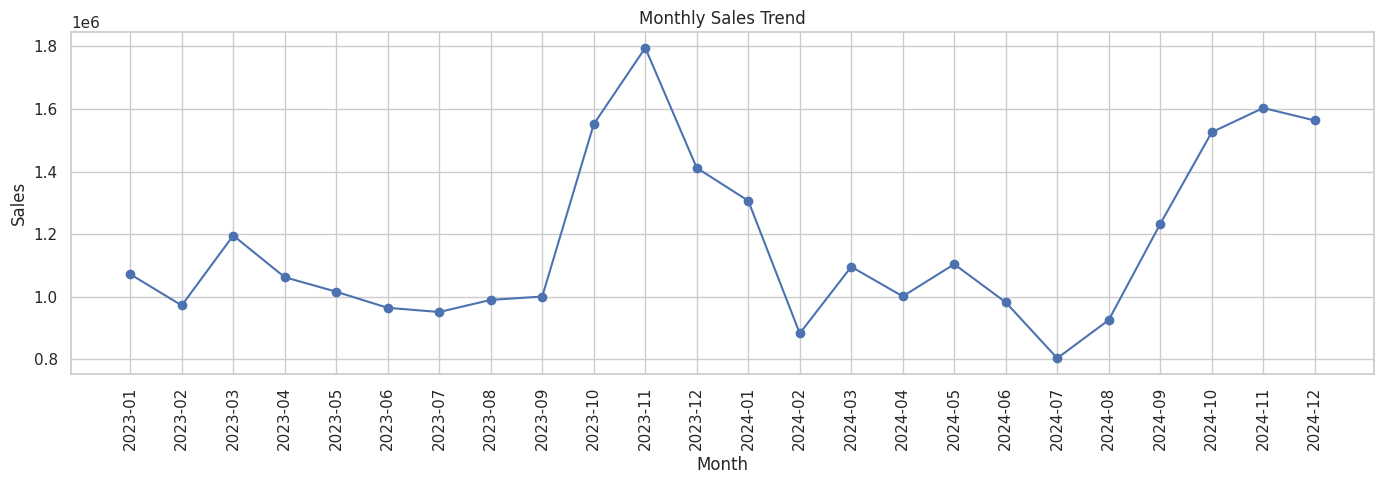

In [6]:
monthly_sales = df.groupby("Month", as_index=False)["Sales"].sum()

plt.figure(figsize=(14, 5))
plt.plot(monthly_sales["Month"], monthly_sales["Sales"], marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Monthly sales are not flat across the two years. The stronger sales periods are mainly toward the end of the year. November 2023 is the highest individual month in this dataset, followed by November and December 2024 and October 2023/2024.

## 7. Time Series Analysis – Quarterly Sales

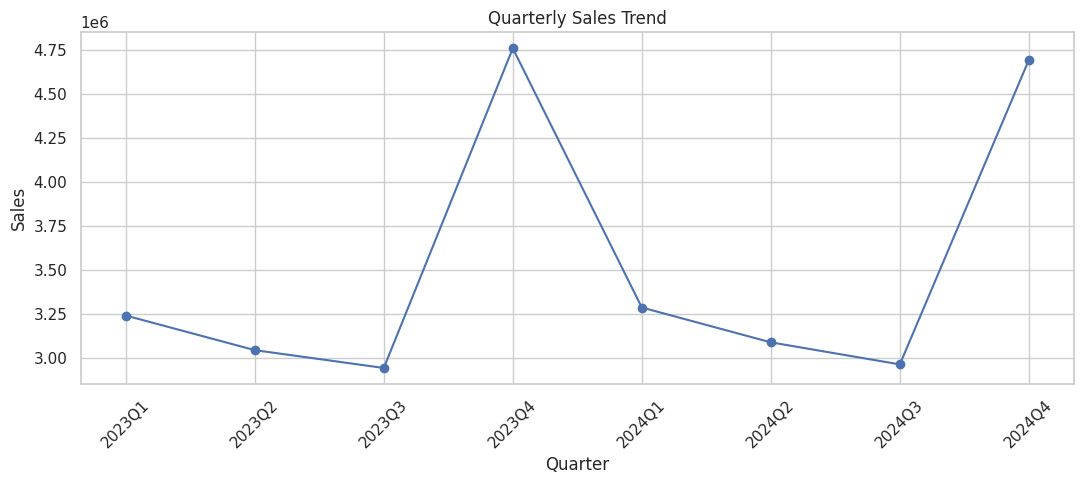

,Quarter,Sales
0,2023Q1,3239331.63
1,2023Q2,3042518.10
2,2023Q3,2941243.23
3,2023Q4,4758268.29
4,2024Q1,3284895.34
5,2024Q2,3086876.05
6,2024Q3,2961488.44
7,2024Q4,4692124.83


In [7]:
quarterly_sales = df.groupby("Quarter", as_index=False)["Sales"].sum()

plt.figure(figsize=(11, 5))
plt.plot(quarterly_sales["Quarter"], quarterly_sales["Sales"], marker="o")
plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

quarterly_sales

The fourth quarter is clearly stronger than the other quarters in both years. This suggests that the business should pay extra attention to inventory, promotions and marketing preparation before Q4.

## 8. Customer Demographics – Age Groups

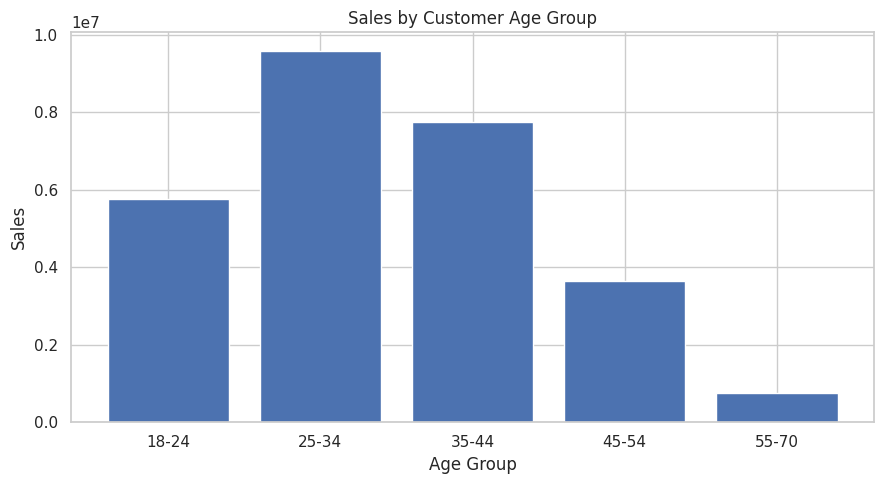

In [8]:
age_sales = df.groupby("Age_Group", observed=False)["Sales"].sum().reset_index()

plt.figure(figsize=(9, 5))
plt.bar(age_sales["Age_Group"].astype(str), age_sales["Sales"])
plt.title("Sales by Customer Age Group")
plt.xlabel("Age Group")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

The 25–34 age group contributes the highest sales in the dataset, followed by customers aged 35–44. The 55–70 group contributes much less sales than the other age groups. This can help when planning customer-specific campaigns.

## 9. Customer Demographics – Gender

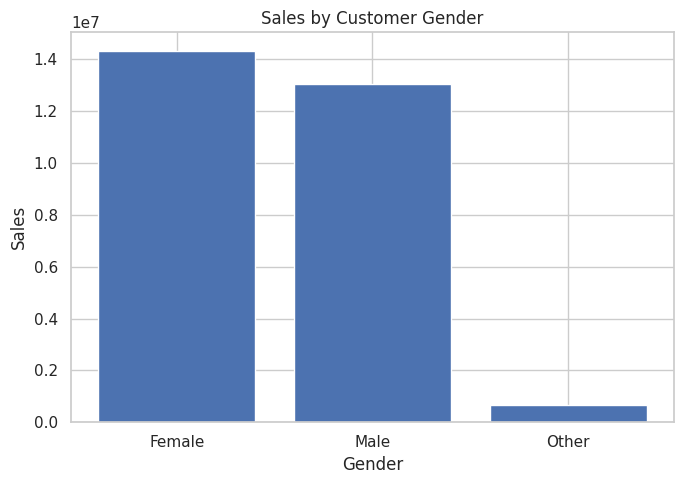

In [9]:
gender_sales = df.groupby("Customer_Gender")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(7, 5))
plt.bar(gender_sales.index, gender_sales.values)
plt.title("Sales by Customer Gender")
plt.xlabel("Gender")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

Female customers account for the largest share of sales, followed by male customers. The 'Other' group is much smaller in this dataset. This is a descriptive result from the available data and should be used carefully when planning campaigns.

## 10. Product Analysis – Top 10 Products

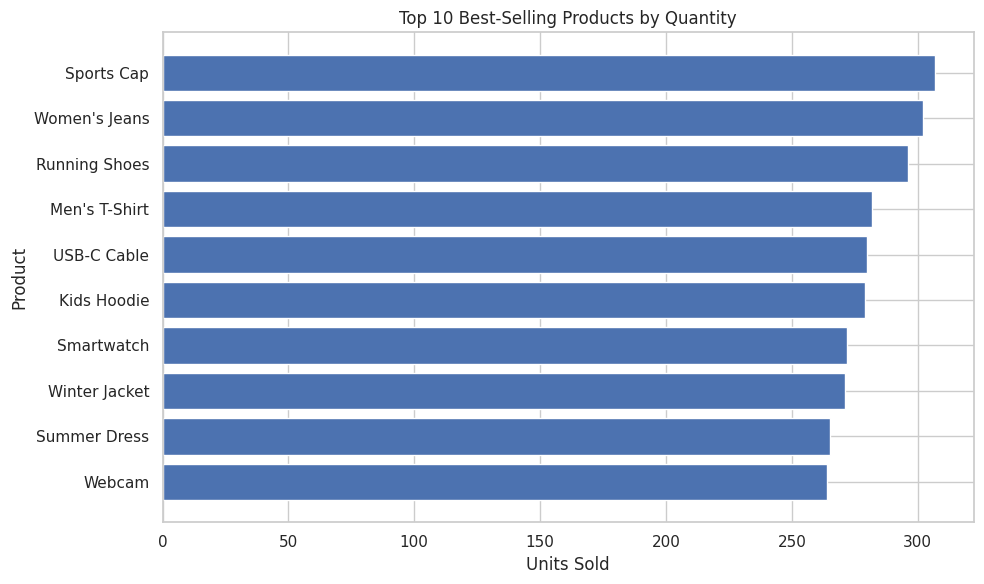

Product_Name
Sports Cap       307
Women's Jeans    302
Running Shoes    296
Men's T-Shirt    282
USB-C Cable      280
Kids Hoodie      279
Smartwatch       272
Winter Jacket    271
Summer Dress     265
Webcam           264
Name: Quantity, dtype: int64

In [10]:
top_products = (
    df.groupby("Product_Name")["Quantity"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .sort_values()
)

plt.figure(figsize=(10, 6))
plt.barh(top_products.index, top_products.values)
plt.title("Top 10 Best-Selling Products by Quantity")
plt.xlabel("Units Sold")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

top_products.sort_values(ascending=False)

Sports Cap has the highest total quantity sold, followed by Women's Jeans and Running Shoes. The ranking is based on units sold, so it shows product volume rather than revenue.

## 11. Product Analysis – Revenue by Category

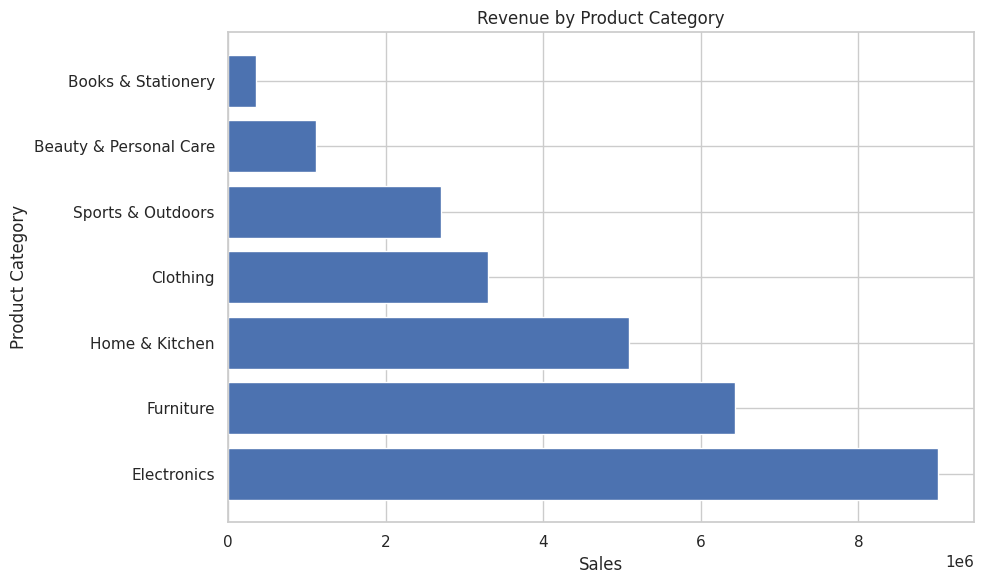

In [11]:
category_sales = (
    df.groupby("Product_Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))
plt.barh(category_sales.index, category_sales.values)
plt.title("Revenue by Product Category")
plt.xlabel("Sales")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

Electronics generates the highest sales among the product categories, followed by Furniture and Home & Kitchen. Electronics also has the highest total profit in this dataset, making it an important category to monitor.

## 12. Correlation Heatmap

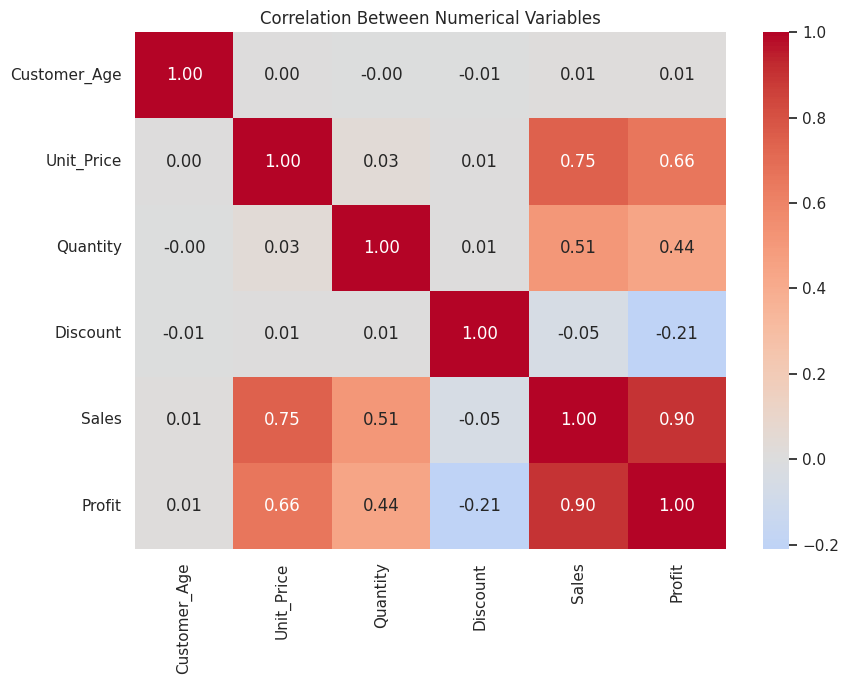

In [12]:
numeric_data = df[
    ["Customer_Age", "Unit_Price", "Quantity", "Discount", "Sales", "Profit"]
]

plt.figure(figsize=(9, 7))
sns.heatmap(numeric_data.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Between Numerical Variables")
plt.tight_layout()
plt.show()

Sales and Profit have a strong positive relationship in this dataset. Sales also has a fairly strong positive relationship with Unit_Price and a moderate positive relationship with Quantity. Discount has a small negative relationship with Sales and a stronger negative relationship with Profit. Correlation shows association, not causation.

## 13. Additional Insight – Sales by Region

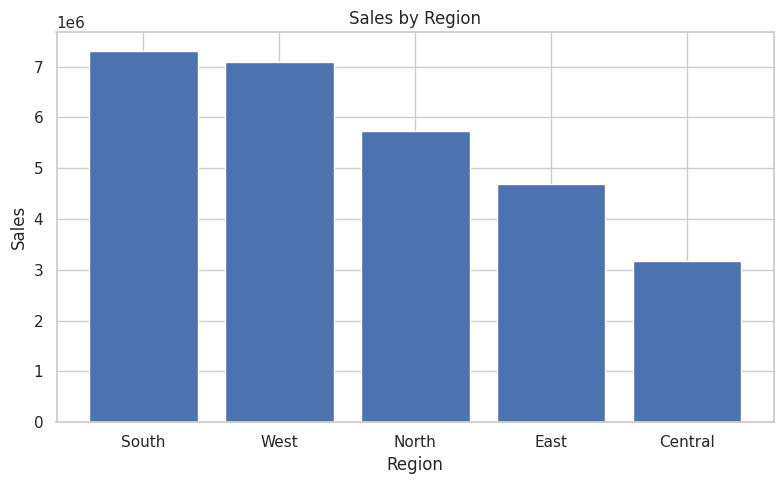

In [13]:
region_sales = (
    df.groupby("Region")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
plt.bar(region_sales.index, region_sales.values)
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

The South and West regions generate the highest sales, while Central has the lowest sales. This regional difference is useful for deciding where to review demand, product availability and local marketing activity.

## 14. Key Findings

- Total sales in the dataset are about **28.01 million**, with total profit of about **7.48 million**.
- Q4 is the strongest quarter in both 2023 and 2024.
- Customers aged **25–34** contribute the highest sales among the age groups used here.
- **Electronics** is the largest product category by sales.
- The **South** region has the highest total sales, closely followed by the West.
- The correlation analysis shows that higher Unit_Price and Quantity are associated with higher Sales, while Discount has a negative association with Profit.

## 15. Business Recommendations

### 1. Prepare early for Q4 demand
Sales are consistently stronger in Q4. Inventory and promotional planning should be completed before the quarter begins so popular products are less likely to face stock pressure.

### 2. Focus product planning on Electronics
Electronics contributes the highest sales and profit among the categories. The business can monitor stock levels, identify its strongest electronics products and use targeted promotions instead of applying the same approach to every category.

### 3. Build campaigns around the 25–34 customer group
This age group contributes the highest sales. Customer campaigns and product recommendations can be tailored to this group while still testing offers for other age groups.

### 4. Review regional performance
South and West are the strongest regions, while Central has the lowest sales. Comparing product mix, customer segments and marketing activity across these regions can help identify why performance differs.

## 16. Conclusion

This EDA helped me understand the main sales, customer and product patterns in the retail dataset. The biggest patterns were the strong Q4 sales, the high contribution from the 25–34 age group, and the strong performance of Electronics. These findings can be used as a starting point for better inventory planning, customer targeting and regional analysis.

The next step would be to go deeper into product-level profitability and customer purchase behaviour rather than looking only at overall sales.

## 17. Project Notes

**Tools used:** Python, pandas, matplotlib, seaborn and Jupyter Notebook.

**Dataset period:** January 2023 to December 2024.

**Note:** Missing Customer_Age and Payment_Mode values were kept as missing instead of replacing them with assumed values.